# Basic usage

Using `ghostID` is simple. In this example we'll implement the normal form of the saddle-node bifurcation in 2D:

$$ \dot x = \mu + x^2, \quad \dot y = -y,$$

For $\mu>0$ the system doesn't have any fixed points but instead a significant ghost or bottleneck for small enough values of $\mu$.
In the code below we import some packages, define the model and simulate a trajectory. Note that only `jax.numpy` is strictily necessary to define the ODE system as `ghostID` runs on `jax` models for improved performance. Instead of using `solve_ivp` you can also use a method from `jax` for faster simulations.

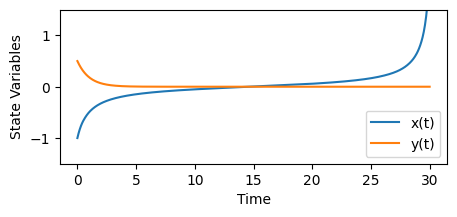

In [42]:
# imports
import numpy as np
import jax.numpy as jnp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# define
def normalform_SN_bifurcation(t,z,para):

    mu=para[0]
    dx = mu + z[0]**2
    dy= -z[1]
         
    return jnp.stack([dx, dy])

# set model parameters
mu = 0.01

# set time parameters
dt = 0.05
t_end = 30
timesteps = np.linspace(0,t_end,int(t_end/dt))

# initial conditions
x0 = -1
y0 = 0.5

# run simulation
sol = solve_ivp(normalform_SN_bifurcation, (0, t_end), [x0,y0], t_eval=timesteps, args=([mu],),method='RK45')

# plot time series
plt.figure(figsize=(5,2))
plt.plot(sol.t, sol.y[0], label='x(t)')
plt.plot(sol.t, sol.y[1], label='y(t)')
plt.ylim([-1.5, 1.5])
plt.xlabel('Time')
plt.ylabel('State Variables')
plt.legend()


While $y(t)$ quickly reaches 0, $x(t)$ lingers for a long time in the vicinity of 0 - that's our ghost - and eventually takes off to approach infinity.
Once we have the simulation, we simply import `PyGhostID`, extract the trajectory from the solution object provided by `solve_ivp`, and use the `ghostID` function to identify the ghost. The required arguments are the *model function*, the *model parameters*, *stepsize* used during the simulation, and the *trajectory* - in this specific order.

In [47]:
# import PyGhostID package
import PyGhostID as gid

# extract trajectory
trajectory=sol.y.T

# run ghostID
ghostSeq = gid.ghostID(normalform_SN_bifurcation,[mu],dt,trajectory)

`ghostID` returns a `ghostSeq` - a list of dictionaries, each representing a distinct ghost that has been identified along the given trajectory. Each dictionary contains several datafields which provide information about the ghost, e.g. a unique identifier, the trapping time at the ghost, its position in phase space etc (see Figure 1b above). We can print each ghost from the ghostSeq to learn more:

In [48]:
for g in ghostSeq:
    print(g)

{'id': 'G1', 'time': np.float64(14.700000000000001), 'duration': np.float64(24.94254253066653), 'position': array([2.07808102e-05, 3.60455693e-07]), 'dimension': 1, 'q-value': np.float32(0.005), 'crossing_eigenvalues': array([0]), 'qualifying_slopes': [], 'eigenvalues_qmin': array([ 0.09935497+0.j, -1.        +0.j], dtype=complex64)}


We can see that the ghostSeq isn't empty and that `ghostID` has identified a single ghost along the trajectory we have analyzed.
The datafields are very useful for further analysis. For example, we can extract the position of the identified ghost in phase space and thereby plot it:

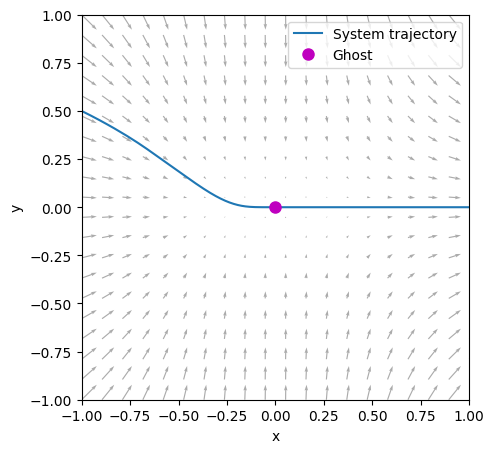

In [49]:
plt.figure(figsize=(5,5))

# plot trajectory
plt.plot(sol.y[0], sol.y[1], label='System trajectory')

# plot vector field
x = np.linspace(-1, 1, 20)
y = np.linspace(-1, 1, 20)
X, Y = np.meshgrid(x, y)
plt.quiver(X, Y, mu + X**2, -Y, color='gray', alpha=0.66)

# extract and plot position of ghost
gx,gy = ghostSeq[0]["position"]

plt.plot(gx,gy,"om",ms=8,label='Ghost')

plt.xlim([-1,1]); plt.xlabel('x')
plt.ylim([-1,1]); plt.ylabel('y')
plt.legend()
plt.show()